# Pràctica 1:

Nom dels alumnes del grup: Mario Vilar i David Díez

# Anàlisi exploratòria de dades (EDA) & ús d'eines avançades de Python

L'**anàlisi exploratòria de dades** (EDA, per les seves sigles en anglès, *Exploratory Data Analysis*) és un procés crític en la ciència de les dades que implica **explorar, resumir i visualitzar** les dades per a entendre les seves característiques principals. L'objectiu principal de l'EDA és revelar patrons, tendències i anomalies a partir de les dades, sense fer suposicions massa específiques o construir models massa complexes.

Aquí teniu alguns dels elements més importants de l'anàlisi exploratòria de dades:

+ **Visualització de dades**: A través de gràfics i gràfiques, es representen les dades per a veure distribucions, tendències i relacions. Això pot incloure histogrames, gràfics de barres, diagrames de dispersió, gràfics de caixa, etc.

+ **Estadístiques descriptives**: Es calculen estadístiques com la mitjana, la mediana, la desviació estàndard i altres mesures resum per a descriure les característiques bàsiques de les variables.

+ **Detecció d'anomalies**: Es busca identificar valors atípics o anòmals que puguin indicar errors o situacions especials en les dades.

+ **Imputació de dades faltants**: Si les dades tenen buits o valors faltants, es pot decidir com omplir aquests buits de manera adequada.

+ **Exploració de relacions**: Es busquen correlacions i relacions entre les diferents variables de les dades per a identificar connexions i dependencies.

+ **Agrupació de dades**: Es divideixen les dades en subconjunts basats en certes característiques per a analitzar-les més detingudament.

+ **Transformació de dades**: Es poden aplicar transformacions a les dades per a fer-les més adequades per a anàlisi posterior, com l'estandardització o la normalització.

* **Selecció de característiques**: Si es treballa amb un conjunt de dades amb moltes variables, es pot realitzar una selecció de característiques per a reduir la complexitat i millorar l'eficiència de l'anàlisi.

Python ofereix una àmplia gamma d'eines i biblioteques per a realitzar l'anàlisi exploratòria de dades (EDA). Algunes de les biblioteques més populars i útils són les següents:

+ **NumPy**: NumPy és una biblioteca fonamental per a la computació científica en Python. Proporciona funcionalitats per a treballar amb matrius i vectors, la qual cosa és essencial per a l'anàlisi de dades.

+ **Pandas**: Pandas és una biblioteca molt popular per a l'anàlisi de dades que ofereix estructures de dades com DataFrame i Series, que faciliten la manipulació i anàlisi de dades tabulars. Podeu utilitzar Pandas per a carregar, netejar i explorar les dades.

+ **Matplotlib**: Matplotlib és una biblioteca per a la visualització de dades que us permet crear una àmplia gamma de gràfics i gràfiques personalitzades. És ideal per a crear histogrames, diagrames de dispersió, gràfics de barres i moltes altres representacions gràfiques.

+ **Scipy**: SciPy és una biblioteca que amplia les funcionalitats de NumPy i proporciona eines addicionals per a l'anàlisi científic, inclosos estadístics i mètodes d'optimització.

+ **Scikit-learn**: Si esteu interessats en l'aprenentatge automàtic, Scikit-learn és una biblioteca essencial que ofereix eines per a la classificació, regressió, agrupació i altres tasques d'aprenentatge automàtic. També conté eines per a la selecció de característiques.

+ **Seaborn**: Seaborn és una biblioteca de visualització de dades basada en Matplotlib que simplifica la creació de gràfics estadístics atractius i informatius. És especialment útil per a la visualització de relacions i tendències en les dades.

## 0. Objectiu de la pràctica

L'**objectiu d'aquesta pràctica** és aprendre com fer una exploració sobre un conjunt de dades real, que al final ens permeti obtenir la resposta a diverses preguntes.

En aquesta pràctica explorarem les dades dels trajectes dels **taxis grocs de la ciutat de Nova York** durant varios anys.

En finalitzar aquesta pràctica, haureu de ser capaços de respondre la pregunta següent de forma detallada:

- **Com va afectar la pandèmia de la Covid l'ús dels taxis a Nova York?**

Pere respondre aquesta pregunta tant genèrica, ho descomposarem en preguntes més concretes:

- Quina distribució d'encàrrecs segueixen els taxis i quina distància / durada tenen?
- Quines són les zones on m'és / menys taxis s'agafen?
- Quins horaris són els més usuals?
- Quins dies de la setmana i del mes s'utilitzen més?
- Etc.

### Instal·lació i importació de les llibreries necessàries

A més a més de les llibreries comentades, farem servir aquests mòduls de Python:

+ **PyArrow**: PyArrow és una biblioteca de Python que es fa servir per a l'intercanvi eficient de dades entre Python i altres llenguatges de programació, especialment C++ i Java. Aquesta biblioteca es desenvolupa com a part del projecte Apache Arrow, que és un projecte de codi obert dissenyat per a millorar el rendiment i la interoperabilitat de l'analítica de dades i les tecnologies relacionades. PyArrow permet la creació i la manipulació eficient de dades en forma de taules i columnes. PyArrow ofereix suport per a l'estructura de dades coneguda com a "Table", que és similar a una taula o un quadern de dades en altres llenguatges. Aquesta estructura de dades facilita l'organització i la manipulació de dades tabulars.

In [ ]:
from platform import python_version
print(python_version())

3.10.12


In [ ]:
! pip install pyarrow

In [ ]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os
from tqdm.notebook import tqdm
import pyarrow.parquet as pq

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Descàrrega de dades

In [ ]:
# Variables globals: els anys que estudiarem
YEARS = [2019, 2020, 2021]

In [ ]:
# Descàrrega de les dades: Trip Record Data
# https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page

for year in tqdm(YEARS):
    if not os.path.exists(f'data/{year}'):
        os.makedirs(f'data/{year}', exist_ok=True)
        for month in tqdm(range(1, 13)):
            urllib.request.urlretrieve(f'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet', f'data/{year}/{month:02d}.parquet')

  0%|          | 0/3 [00:00<?, ?it/s]

## 2. Neteja de dades

Per tal de tenir unes dades netes i útils, eliminarem totes aquells trajectes (files del conjunt de dades)  que continguin informació *corrupte*. Per exemple, cal verificar que no es dóna cap d'aquests casos:

- Presència de *missing data* (camps/columnes de les dades sense valor).
- L'hora de recollida és posterior a la finalització del trajecte.
- Les dades s'importen per mes i any. Són coherents els valors que contenen les dades?
- Hi ha viatges amb un nombre absurd de passatgers?
- Hi ha viatges massa llargs o massa curts?
- Hi ha pagaments negatius?
- Etc.

A més a més, hem de considerar aspectes concrets d'aquestes dades:

+ Hi pot haver viatges impossibles segons la normativa:
    + [Més viatgers que els permesos](https://www1.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page) o [velocitats il·legals](https://www.speed-limits.com/newyork).
    + [Limit de persones permeses a un yellow taxicab](https://drive.google.com/file/d/1eiV7wdm7WrkRlM9bmekCRM6GY3Yq6GI2/view?usp=sharing)

De totes les columnes que tenen les dades, només cal fer servir les següents per contestar les preguntes:

- *tpep_pickup_datetime*: The date and time when the meter was engaged.
- *tpep_dropoff_datetime*: The date and time when the meter was disengaged.
- *Passenger_count*: The number of passengers in the vehicle.
- *Trip_distance*: The elapsed trip distance in miles reported by the taximeter.
- *PULocationID*: TLC Taxi Zone in which the taximeter was engaged
- *DOLocationID*: TLC Taxi Zone in which the taximeter was disengaged
- *Payment_type*: A numeric code signifying how the passenger paid for the trip.
    - 1= Credit card
    - 2= Cash
    - 3= No charge
    - 4= Dispute
    - 5= Unknown
    - 6= Voided trip
- *Fare_amount*: The time-and-distance fare calculated by the meter.
- *Total_amount*: The total amount charged to passengers.

In [ ]:
# Carreguem les dades a un dataframe de pandas
# Per agilitzar els càlculs i reduir el temps de càlcul durant el desenvolupament,
# eliminem les columnes que no són útils i treballem amb una mostra
# uniforme de les dades (1 fila de cada 100).

def load_table(year, month, sampling = 100):
    """
    Funció que llegeix les dades descarregades i les converteix a un DataFrame
    """
    data = pq.read_table(f'data/{year}/{str(month).zfill(2)}.parquet').to_pandas()
    required_data = ['tpep_pickup_datetime',
                 'tpep_dropoff_datetime',
                 'passenger_count',
                 'trip_distance',
                 'PULocationID',
                 'DOLocationID',
                 'payment_type',
                 'fare_amount',
                 'total_amount']
    return data[required_data][::sampling]

In [ ]:
# Explorem una mica les dades
test = load_table(2019, 1)
test.shape

(76967, 9)

In [ ]:
test.tail(10)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,total_amount
7695700,2019-01-30 22:40:39,2019-01-30 22:41:55,NaN,0.17,256,256,0,39.95,43.0
7695800,2019-01-31 06:58:00,2019-01-31 07:44:00,NaN,17.57,108,56,0,77.45,81.0
7695900,2019-01-31 07:46:00,2019-01-31 08:37:00,NaN,10.85,91,231,0,37.19,46.5
7696000,2019-01-31 09:00:00,2019-01-31 09:45:00,NaN,4.11,162,231,0,35.95,39.5
7696100,2019-01-31 11:18:35,2019-01-31 11:41:41,NaN,4.52,244,75,0,29.45,32.5
7696200,2019-01-31 14:01:00,2019-01-31 15:08:00,NaN,16.32,36,21,0,59.15,62.7
7696300,2019-01-31 15:35:00,2019-01-31 15:55:00,NaN,4.96,18,220,0,26.31,32.5
7696400,2019-01-31 17:11:00,2019-01-31 18:05:00,NaN,14.78,107,130,0,50.69,60.0
7696500,2019-01-31 18:33:00,2019-01-31 18:58:00,NaN,8.80,107,69,0,39.45,43.0
7696600,2019-01-31 23:31:07,2019-01-31 23:51:40,NaN,9.17,140,47,0,43.45,46.5


###  Exercici A

+ Un cop llegides les dades a una taula de Pandas, implementa una funció que faci el procés de neteja que consideris necessari. Per determinar què és necessari, **explora** els valors que apareixen a cada columna del dataframe de Pandas i decideix què cal fer.

> *Nota: Les columnes `Datatime` són un subtipus de dades de Pandas anomenades `datetime`.  Busca com tractar de forma eficient aquest tipus de dades en Pandas.*

In [ ]:
# Calcular els dos percentils i filtrar les dades, SOLAMENT UN COP!!
# Finalment hem decidit no usar-la perque retallava moltes dades

percentile_lower_time = {}
percentile_higher_time = {}
MAX_TRIM_PERCENTAGE = 0.05

def filter_by_percentile(data, name, lower, higher):
    """
    Filtra les dades basant-se en percentils especificats, assegurant-se que no es retalli
    més d'un percentatge màxim de dades.

    Parameters:
    - data (DataFrame): El DataFrame a filtrar.
    - name (str): El nom de la columna sobre la qual aplicar el filtratge.
    - lower (float): Percentil inferior (entre 0 i 1).
    - higher (float): Percentil superior (entre 0 i 1).
    - max_trim_percentage (float): Percentatge màxim de dades que es poden eliminar (entre 0 i 1).

    Returns:
    - DataFrame: El DataFrame filtrat o original si es supera el límit de retallada.
    """

    # Calcula el percentatge total que es retallarà
    trim_pct = lower + (1 - higher)

    if trim_pct > MAX_TRIM_PERCENTAGE:
        # Si el percentatge supera el màxim permès, no retalla
        print(f"Retallada del {trim_pct*100:.2f}% excedeix el màxim permès de {MAX_TRIM_PERCENTAGE*100:.2f}%.")
        return data

    if name not in percentile_lower_time and name not in percentile_higher_time:
        # Calcula els valors dels percentils
        lower_bound = data[name].quantile(lower)
        upper_bound = data[name].quantile(higher)

        # Emmagatzema els percentils globals
        percentile_lower_time[name] = lower_bound
        percentile_higher_time[name] = upper_bound

        # Aplica el filtratge
        trimmed_data = data[(data[name] >= lower_bound) & (data[name] <= upper_bound)]
        removed_data = len(data[(data[name] < lower_bound) | (data[name] > upper_bound)])
        print(f"S'han eliminat un total de {removed_data}")
        return trimmed_data

    else:
        # Si ja hi ha percentils calculats, permet canvis si la nova cota és més restrictiva
        lower_bound = data[name].quantile(lower)
        upper_bound = data[name].quantile(higher)

        # Permet canviar si la nova cota inferior és més alta o la cota superior més baixa
        if lower_bound > percentile_lower_time[name] or upper_bound < percentile_higher_time[name]:
            # Actualitza els percentils globals si hi ha una restricció més estricta
            percentile_lower_time[name] = max(lower_bound, percentile_lower_time[name])
            percentile_higher_time[name] = min(upper_bound, percentile_higher_time[name])

            # Aplica el filtratge amb els nous valors
            trimmed_data = data[(data[name] >= percentile_lower_time[name]) & (data[name] <= percentile_higher_time[name])]
            removed_data = len(data[(data[name] < percentile_lower_time[name]) | (data[name] > percentile_higher_time[name])])
            print(f"S'han eliminat un total de {removed_data}")
            return trimmed_data
        else:
            # Si el filtratge no és més estricte, no es fa res
            print(f"Ja s'ha aplicat una restricció tant o més estricta per la columna {name}. No es pot fer més laxa.")
            return data

In [ ]:
def clean_data(data, year, month):
    """
    Funció que neteja (una mostra de) les dades per un mes donat.

    Parameters:
    - data (DataFrame): El DataFrame a filtrar.
    - year (int): Any que estem filtrant.
    - month (int): Mes que estem estudiant.

    Returns:
    - DataFrame: El DataFrame filtrat o original si es supera el límit de retallada.
    """

    # Carreguem les dades
    data = load_table(year, month)

    # 0. Eliminem els duplicats
    data = data.drop_duplicates()

    # 1. Presència de missing data (camps/columnes de les dades sense valor).
    data = data.dropna()

    # 2. L'hora de recollida és posterior a la finalització del trajecte.
    data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
    data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])
    data = data[data['tpep_pickup_datetime'] < data['tpep_dropoff_datetime']]

    # 3. Les dades s'importen per mes i any. Són coherents els valors que contenen les dades?
    data = data[data['tpep_pickup_datetime'].dt.year == year]
    data = data[data['tpep_pickup_datetime'].dt.month == month]

    # 4. Hi ha viatges amb un nombre absurd de passatgers? (considerem que poden haver fins a 7 passatgers a les furgonetes)
    data = data[(data['passenger_count'] >= 0) & (data['passenger_count'] < 7)]

    # 5. Hi ha pagaments negatius o nuls?
    data = data[(data['fare_amount'] > 0) & (data['total_amount'] > 0) & (data['total_amount'] > data['fare_amount'])]

    # 6. Els tipus de pagament són vàlids?
    valid_payment_types = [1, 2, 3, 4]
    data = data[(data['payment_type'].isin(valid_payment_types))]

    # 7. Comprovem que el PULocationID i el DOLocationID siguin correctes
    data = data[(data['PULocationID'] >= 1) & (data['PULocationID'] <= 263) & (data['DOLocationID'] >= 1) & (data['DOLocationID'] <= 263)]

    # Fem reset del índex per tenir-ho actualitzat
    data.reset_index(drop=True, inplace=True)

    return data

test = clean_data(test, 2019, 1)
test.shape

(74736, 9)

Hem decidit que els tipus de pagament seran aquests (1, 2, 3 i 4) ja que les circumstàncies en què es poden haver produït els altres (5 i 6) poden ser molt diverses. Primer, no queda clar en quin cas es podria produir `unknown`; després, `voided_trip` significa que el viatge ha estat cancel·lat. Hem decidit deixar `no_charge` perquè podria ser un viatge pagat pel mateix transportista per raons diverses (ofertes, patrocinis...).

Al seu torn, hem decidit que els viatges buits (és a dir, sense passatgers) comptin. És un percentatge significatiu i en tornarem a parlar més endavant.

In [ ]:
test

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.50,151,239,1,7.0,9.95
1,2019-01-01 00:43:00,2019-01-01 00:52:16,1.0,1.60,238,236,1,8.5,12.70
2,2019-01-01 00:30:01,2019-01-01 00:33:50,1.0,0.69,143,239,2,5.0,6.30
3,2019-01-01 00:34:48,2019-01-01 00:46:16,2.0,2.01,236,74,1,10.0,12.88
4,2019-01-01 00:49:44,2019-01-01 01:07:18,2.0,3.50,263,164,1,14.5,18.95
...,...,...,...,...,...,...,...,...,...
74731,2019-01-31 23:58:14,2019-02-01 00:04:05,2.0,0.53,230,48,1,5.5,8.84
74732,2019-01-31 23:13:39,2019-01-31 23:19:36,1.0,2.19,142,151,1,8.0,11.16
74733,2019-01-31 18:44:20,2019-01-31 18:50:12,1.0,0.59,161,162,2,5.5,6.80
74734,2019-01-31 23:26:07,2019-02-01 00:02:33,1.0,4.02,161,226,1,24.0,29.30


###  Exercici B

+ Escriu una funció que transformi la taula original a una nova taula, més adequada per tal de dur a terme l'exploració necessària. Podeu afegir columnes addicionals, precalcular valors, etc.

> Per exemple, podem transformar les dades per treballar amb les unitats de kilòmetres i hores per a representar les durades, distàncies i velocitats del trajecte. El motiu és, per una banda, que estem familiaritzades amb el Sistema Internacional d'Unitats (d'aquí el canvi de milles a km). I per altra, optar pels km i no pels metres degut a l'ordre de magnitud de les dades.

> Un cop tenim les dades normalitzades i enriquides hem de pensar en la neteja una altra vegada. Per exemple: Eliminar aquelles files que tinguin velocitat max excedeixi limit permès per llei https://www.speed-limits.com/newyork

In [ ]:
MILES_TO_KM = 1.60934

def post_processing(df):
    """
    Funció on implementar qualsevol tipus de postprocessament necessari.

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.

    Returns:
    - DataFrame: El DataFrame amb les noves columnes.
    """

    data = df.copy()

    # 0. Hi ha viatges massa llargs o massa curts?
    # Calcular el temps del viatge en hores (ho podem fer perque ja hem filtrat
    # les diferències negatives) i filtrem aquells que no tinguin sentit
    # com ara aquells que duren menys d'un minut (0.0166667 hores) i 4 hores
    data['travel_time'] = data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']
    data['travel_time'] = data['travel_time'].dt.total_seconds() / 3600
    data = data[(data['travel_time'] > 0.016) & (data['travel_time'] <= 4)]

    # 1. Passem les milles a km
    data['trip_distance'] = data['trip_distance'] * MILES_TO_KM

    # 2. Eliminem els viatges amb distancia irreal (superior a 150 km o inferior a 100 m)
    data = data[(data['trip_distance'] <= 150) & (data['trip_distance'] > 0.1)]

    # 3. Filtrem per les velocitats mitjanes
    data['avg_speed'] = data['trip_distance'] / data['travel_time']
    data = data[data['avg_speed'] < 65 * MILES_TO_KM]

    # 4. Filtrem pel preu per km
    data['price_km'] = data['total_amount'] / data['trip_distance']

    # 5. Filtrem pel preu per minut
    data['price_min'] = data['total_amount'] / (data['travel_time'] * 60)

    # 6. Afegim una columna hour
    data['pickup_hour'] = data['tpep_pickup_datetime'].dt.hour
    data['dropoff_hour'] = data['tpep_dropoff_datetime'].dt.hour

    # 7. Afegim una columna day
    data['pickup_day'] = data['tpep_pickup_datetime'].dt.day
    data['dropoff_day'] = data['tpep_dropoff_datetime'].dt.day

    # 8. Afegim una columna day of the week
    data['pickup_dow'] = data['tpep_pickup_datetime'].dt.dayofweek
    data['dropoff_dow'] = data['tpep_dropoff_datetime'].dt.dayofweek

    # 9. Afegim una columna week of year
    data['pickup_week'] = data['tpep_pickup_datetime'].dt.isocalendar().week
    data['dropoff_week'] = data['tpep_dropoff_datetime'].dt.isocalendar().week

    # 10. Afegim una columna month
    data['month'] = data['tpep_pickup_datetime'].dt.month

    # 11. Afegim una columna year
    data['year'] = data['tpep_pickup_datetime'].dt.year

    # 12. Afegim una columna quarter
    data['quarter'] = data['tpep_pickup_datetime'].dt.quarter

    # 13. Fem reset del índex per tenir-ho actualitzat
    data.reset_index(drop=True, inplace=True)

    return data

post_df = post_processing(test)
post_df.shape

(73819, 24)

In [ ]:
post_df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,total_amount,travel_time,...,dropoff_hour,pickup_day,dropoff_day,pickup_dow,dropoff_dow,pickup_week,dropoff_week,month,year,quarter
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,2.414010,151,239,1,7.0,9.95,0.111111,...,0,1,1,1,1,1,1,1,2019,1
1,2019-01-01 00:43:00,2019-01-01 00:52:16,1.0,2.574944,238,236,1,8.5,12.70,0.154444,...,0,1,1,1,1,1,1,1,2019,1
2,2019-01-01 00:30:01,2019-01-01 00:33:50,1.0,1.110445,143,239,2,5.0,6.30,0.063611,...,0,1,1,1,1,1,1,1,2019,1
3,2019-01-01 00:34:48,2019-01-01 00:46:16,2.0,3.234773,236,74,1,10.0,12.88,0.191111,...,0,1,1,1,1,1,1,1,2019,1
4,2019-01-01 00:49:44,2019-01-01 01:07:18,2.0,5.632690,263,164,1,14.5,18.95,0.292778,...,1,1,1,1,1,1,1,1,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73814,2019-01-31 23:58:14,2019-02-01 00:04:05,2.0,0.852950,230,48,1,5.5,8.84,0.097500,...,0,31,1,3,4,5,5,1,2019,1
73815,2019-01-31 23:13:39,2019-01-31 23:19:36,1.0,3.524455,142,151,1,8.0,11.16,0.099167,...,23,31,31,3,3,5,5,1,2019,1
73816,2019-01-31 18:44:20,2019-01-31 18:50:12,1.0,0.949511,161,162,2,5.5,6.80,0.097778,...,18,31,31,3,3,5,5,1,2019,1
73817,2019-01-31 23:26:07,2019-02-01 00:02:33,1.0,6.469547,161,226,1,24.0,29.30,0.607222,...,0,31,1,3,4,5,5,1,2019,1


Amb això podem crear un nou dataset (una única taula) que contingui tota la informació dels anys: 2019, 2020, 2021.

In [ ]:
data = pd.concat([clean_data(load_table(year, month), year, month)
                for year in tqdm(YEARS)
                for month in tqdm(range(1, 13), leave = False)],
                ignore_index=True, sort=False)

df = post_processing(data)
df.shape

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

(1332549, 24)

In [ ]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,total_amount,travel_time,...,dropoff_hour,pickup_day,dropoff_day,pickup_dow,dropoff_dow,pickup_week,dropoff_week,month,year,quarter
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,2.414010,151,239,1,7.0,9.95,0.111111,...,0,1,1,1,1,1,1,1,2019,1
1,2019-01-01 00:43:00,2019-01-01 00:52:16,1.0,2.574944,238,236,1,8.5,12.70,0.154444,...,0,1,1,1,1,1,1,1,2019,1
2,2019-01-01 00:30:01,2019-01-01 00:33:50,1.0,1.110445,143,239,2,5.0,6.30,0.063611,...,0,1,1,1,1,1,1,1,2019,1
3,2019-01-01 00:34:48,2019-01-01 00:46:16,2.0,3.234773,236,74,1,10.0,12.88,0.191111,...,0,1,1,1,1,1,1,1,2019,1
4,2019-01-01 00:49:44,2019-01-01 01:07:18,2.0,5.632690,263,164,1,14.5,18.95,0.292778,...,1,1,1,1,1,1,1,1,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332544,2021-12-31 23:37:33,2021-12-31 23:53:36,1.0,14.162192,138,141,1,26.0,57.60,0.267500,...,23,31,31,4,4,52,52,12,2021,4
1332545,2021-12-31 23:24:02,2021-12-31 23:35:34,2.0,1.609340,161,237,1,8.5,17.30,0.192222,...,23,31,31,4,4,52,52,12,2021,4
1332546,2021-12-31 23:11:50,2021-12-31 23:36:38,1.0,23.238870,132,198,1,40.0,52.87,0.413333,...,23,31,31,4,4,52,52,12,2021,4
1332547,2021-12-31 23:28:57,2021-12-31 23:35:36,1.0,1.947301,237,229,1,7.0,13.00,0.110833,...,23,31,31,4,4,52,52,12,2021,4


## 3. Visualització de dades anuals

Començarem l'anàlisi de les dades amb la següent pregunta: **S'ha incrementat o ha disminuït amb la covid la quantitat de viatges anuals fets amb taxis?**

Per fer-ho, n'hi ha prou amb crear una figura de barres on es visualitzin la quantitat de viatges per any.

### Exercici C

+ Escriu una funció basada en `matplotlib` que generi aquesta gràfica.

In [ ]:
def bar_plot(df, column, xlabel, ylabel, title):
    """
    Funció que crea una figura de barres a partir del dataframe i
    la columna que conté la informació

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - column (str): Columna que volem filtrar.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    - title (str): Títol de la taula.
    """

    # Comptem els viatges
    trips = df[column].value_counts().sort_index()
    # Alternativament, si volguéssim podríem fer servir
    # trips = df.groupby(column).size()

    # Creem el gràfic
    plt.figure(figsize=(6,6))
    plt.bar(trips.index, trips.values, color='skyblue', alpha=0.7)

    # Anomenem els eixos segons els valors passats per paràmetre
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Mostrem el temps a l'eix x
    plt.xticks(trips.index)

    plt.show()

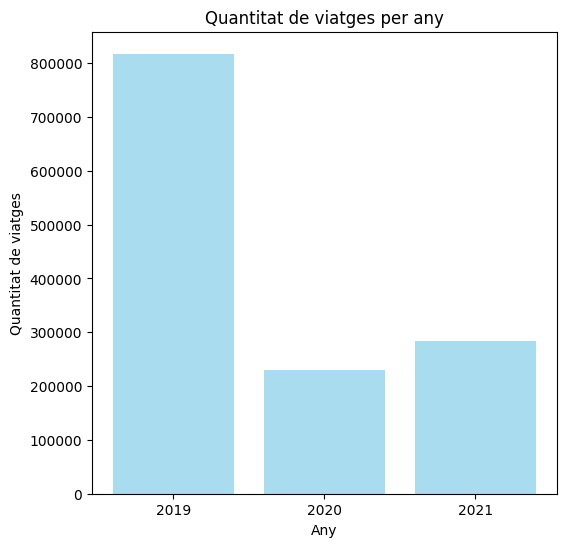

In [ ]:
bar_plot(df,
         'year',
         'Any',
         'Quantitat de viatges',
         'Quantitat de viatges per any')

Aquesta gràfica ens mostra una clara caiguda en la quantitat de viatges per any entre el 2019 i el 2021. El 2019 va ser un any amb un nombre significativament elevat de viatges, superant els 800.000. No obstant, l'any 2020 va experimentar una reducció dràstica del 75% en els viatges, probablement a causa de la pandèmia de la COVID-19, deixant el total d'aquest any en uns 200.000 viatges. L'any 2021, tot i mostrar una recuperació respecte al 2020, encara no va assolir els nivells prepandèmics, mantenint-se per sota dels 400.000 viatges.

Tot i que aquesta gràfica ens ofereix una visió general de la tendència, manca de detalls importants com els factors específics que van contribuir a la recuperació parcial del 2021 i les variacions mensuals o regionals que podrien aportar un major context a l'evolució dels viatges.

+ Visualitza ara en tres gràfiques, el nombre de viatges per mesos de cada any, fent servir la funció anterior.

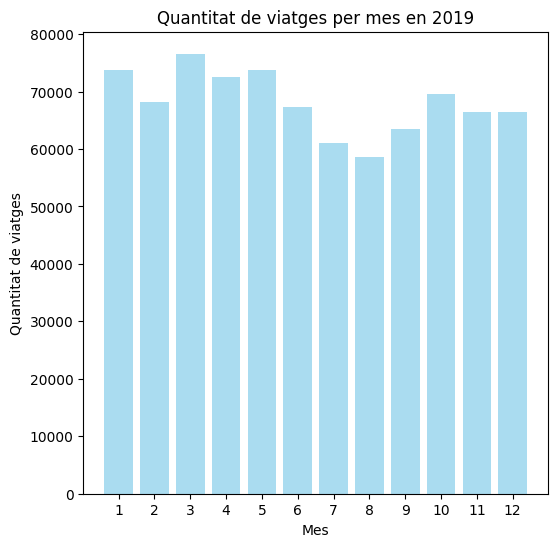

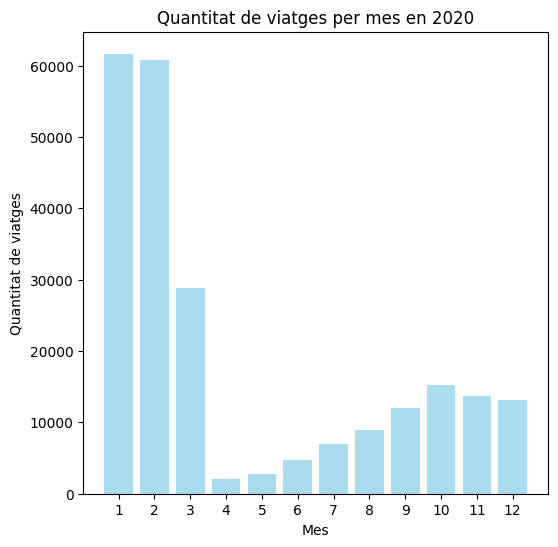

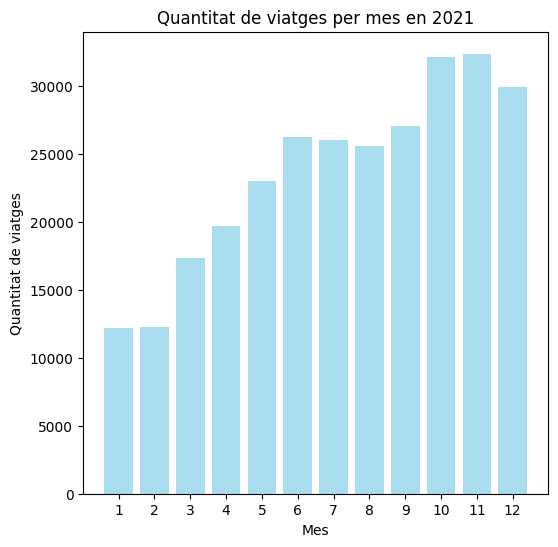

In [ ]:
# Tan sols cridem la funció anterior per cada mes de l'any
for year in YEARS:
    bar_plot(df[df['year'] == year], 'month', 'Mes', 'Quantitat de viatges', f'Quantitat de viatges per mes en {year}')

+ Pregunta:
    + És el comportament que esperàveu? Explica la teva interpretació de les dades tenint en compte el que va passar al món durant aquests anys.

*   Resposta:
    *   Efectivament, a causa de la COVID-19 hem pogut veure un caiguda gegantina en la quantitat de viatges al segon trimestre del 2020. Aquest valor ha anat aumentant de forma progressiva durant tot el 2020 fins a finals del 2021. Val a dir que a finals del 2021 la quantitat de viatges que es feien era quasi un terç dels que es feien abans de la pandèmia.

    * Podem fer una petita observació més detallada pensant que el 2019 és un bon any per obtenir referencies ja que no va haver cap anomalia. Veiem doncs que els primers messos son bastant constants i quan arriba l'estiu la quantitat de viatges baixa, això podria ser per l'estiu i la gent marxant de viatge a un altre lloc. De la mateixa forma, l'últim trimestre de l'any torna a pujar la quantitat de viatges en taxi.

    * El 2020 està marcat pel COVID-19 i es pot veure la caiguda en el segon trimestre de l'any. Observem que els primers messos son igual de constants que l'any 2019 pero entre el març i l'abril la quantitat de viatges baixa significativament. Aquest valor es va recuperant mica en mica durant l'any però res comparat amb el que hi havia al Febrer del 2020.

    * La gràfica del 2021 ens pot enganyar ja que sembla que les barres estiguin molt altes però hem de tenir en compte els valors reals de cada barra. El gener del 2021 hi ha aprox 120.000, just igual que al desembre 2020, i com ja hem dit, no és res comparat amb Febrer 2020 on hi havia 600.000. Val la pena destacar que els viatges en taxi augmenten progressivament en 2021 fins fer el pic el Novembre amb uns 320.000 viatges. És un gran canvi respecte Gener però encara està molt allunyat de les dades de 2019.

+ Visualitza **quants passatgers hi ha per taxi i per any**. Crea una figura **amb tres subfigures** (una per any) on es pugui veure el recompte de passatgers per any. Després repetiu el mateix gràfic visualitzant el % enlloc dels nombres ababsoluts (utilitzeu el paràmetre *norm = True*).

In [ ]:
help(pd.value_counts)

Help on function value_counts in module pandas.core.algorithms:

value_counts(values, sort: 'bool' = True, ascending: 'bool' = False, normalize: 'bool' = False, bins=None, dropna: 'bool' = True) -> 'Series'
    Compute a histogram of the counts of non-null values.
    
    Parameters
    ----------
    values : ndarray (1-d)
    sort : bool, default True
        Sort by values
    ascending : bool, default False
        Sort in ascending order
    normalize: bool, default False
        If True then compute a relative histogram
    bins : integer, optional
        Rather than count values, group them into half-open bins,
        convenience for pd.cut, only works with numeric data
    dropna : bool, default True
        Don't include counts of NaN
    
    Returns
    -------
    Series



In [ ]:
def passengers_taxi_year(df, ylim, xlabel, ylabel, title, norm = False):
    """
    Funció que visualitza quants passatgers hi ha per taxi i per any

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - ylim (range): Límit que tindran els nostres valors.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    - title (str): Títol de la taula.
    - norm (boolean): Indicador sobre si hem de normalitzar o no les dades.
    """

    fig, axs = plt.subplots(1, 3, figsize=(30, 10))
    axs = axs.ravel()

    for i, year in enumerate(YEARS):
        # Filtrem el DataFrame per un any en particular
        yearly_trips = df[df['year'] == year]
        trips_per_passenger = yearly_trips['passenger_count'].value_counts(normalize=norm).sort_index()

        # Mostrem la informació
        bars = axs[i].bar(trips_per_passenger.index, trips_per_passenger.values, color='skyblue', alpha=0.7)
        axs[i].set_xticks(trips_per_passenger.index)
        axs[i].set_title(f'{title} (any {year})')
        axs[i].set_xlabel(xlabel)
        axs[i].set_ylabel(ylabel)
        axs[i].set_ylim(ylim)

        for bar in bars:
          if bar.get_height() < ylim[1]:
            yval = bar.get_height()
            axs[i].text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), ha='center', va='bottom')

    plt.show()

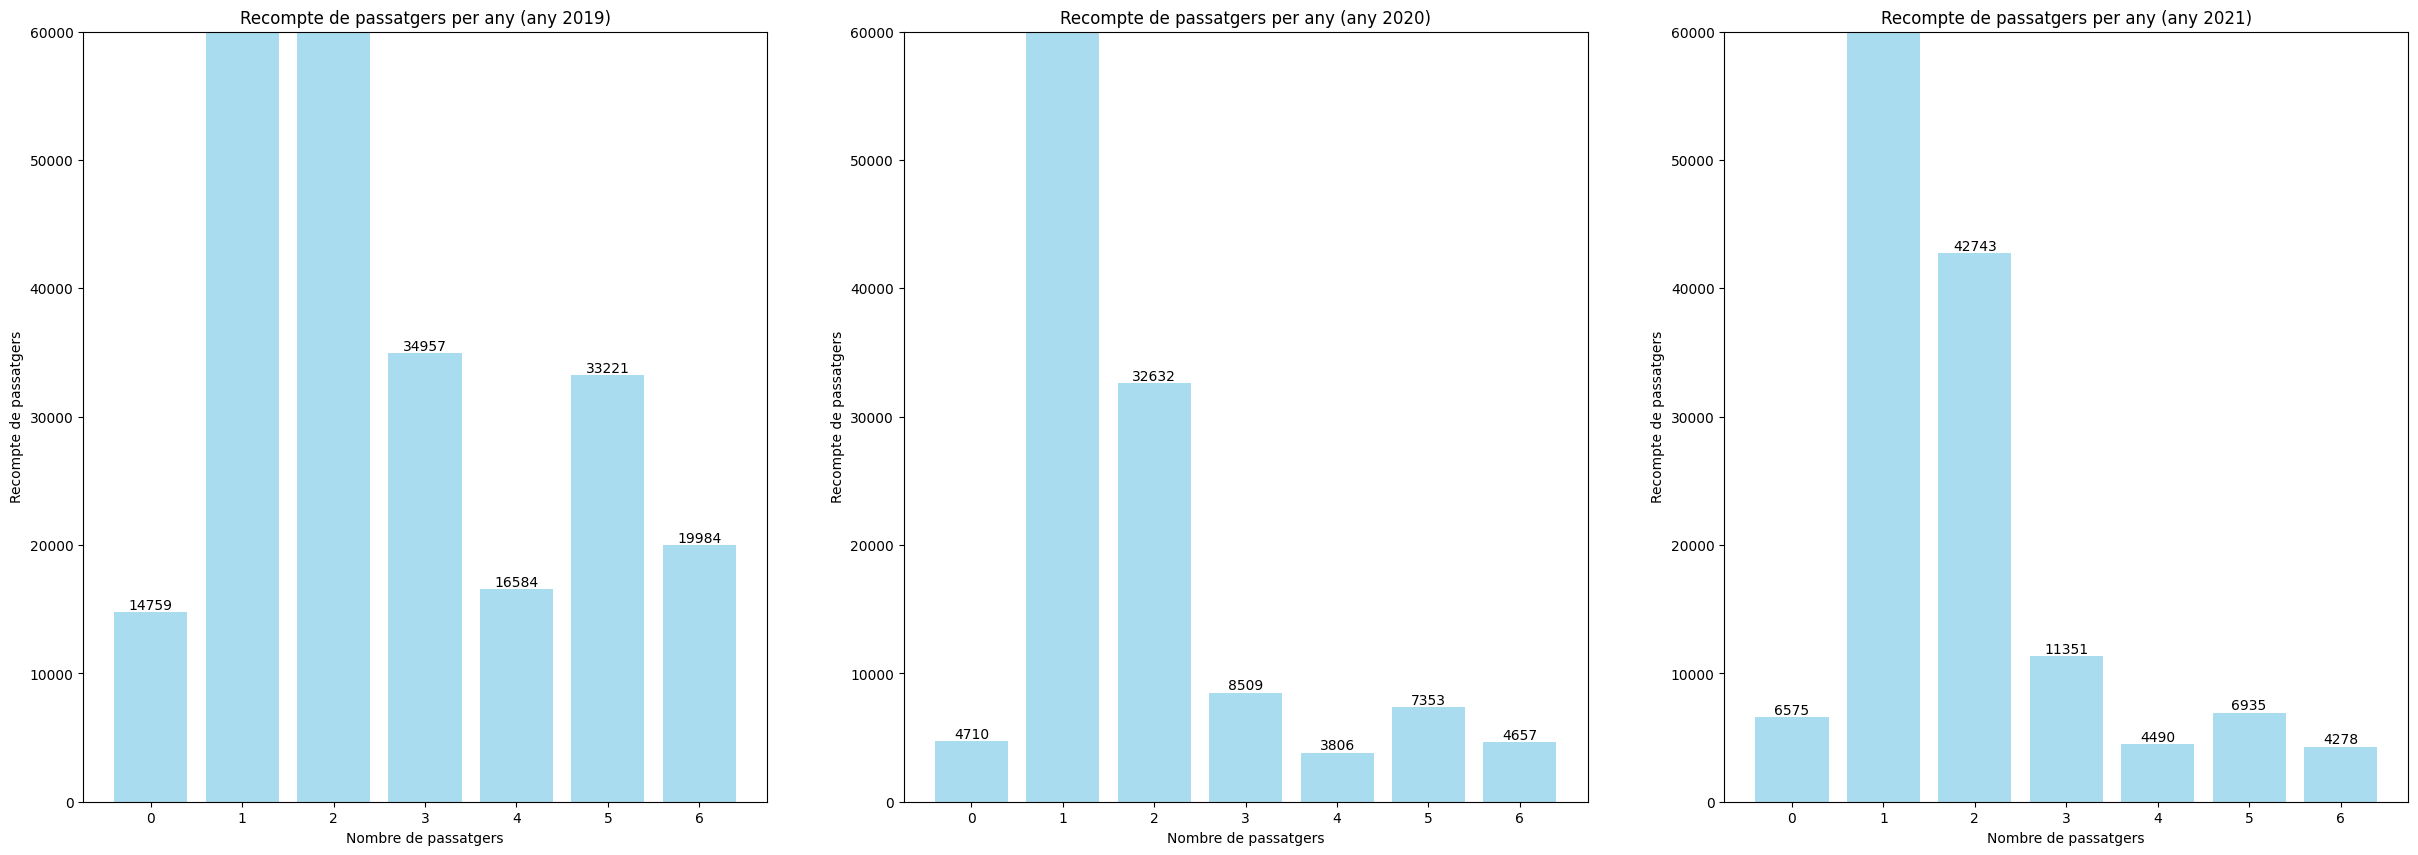

In [ ]:
passengers_taxi_year(df,
                     (0, 60000),
                     'Nombre de passatgers',
                     'Recompte de passatgers',
                     'Recompte de passatgers per any')

* Resposta:
    * Els viatges amb 0 passatgers representen els desplaçaments per recollir algú (per exemple, si algú demana un determinat taxi, el viatge que ha de fer aquest per arribar fins el passatger) i s'han inclòs al recompte de viatges. Podem veure que aquests viatges varien molt entre els tres anys. El 2019 va haver-hi uns 14.759 viatges d'aquest tipus, mentre que el 2020 i 2021 aquesta quantitat es va reduir dràsticament a 4.710 i 6.575 respectivament, probablement a causa de la disminució general de la mobilitat.

    * Observem la diferencia monumental en la quantiatat de viatgers per taxi. Podem veure que els viatges d'un passatger són sempre populars (ja sigui per treball o per oci propi) però al 2019 no som capaços de dir si la moda és 1 o 2 passatgers. D'igual forma, aquests gràfics no ens permeten veure com ha variat la quantitat de viatges amb 1 passatger, l'únic que sabem és que son més de 60.000. Podríem fer la resta de tots els viatges i els que coneixem.
    
    * El que podem observar es que els viatges de 3, 4, 5 i 6 passatgers ha caigut moltíssim amb el pas de la COVID-19. Obviament és dut a terme per les restriccions sanitaries. Per tenir una miqueta d'idea del que va passar, la quantitat de viatges de 5 passatgers al 2019 equival a la quantitat de viatges de 0, 3, 4, 5 i 6 passatgers del 2020.

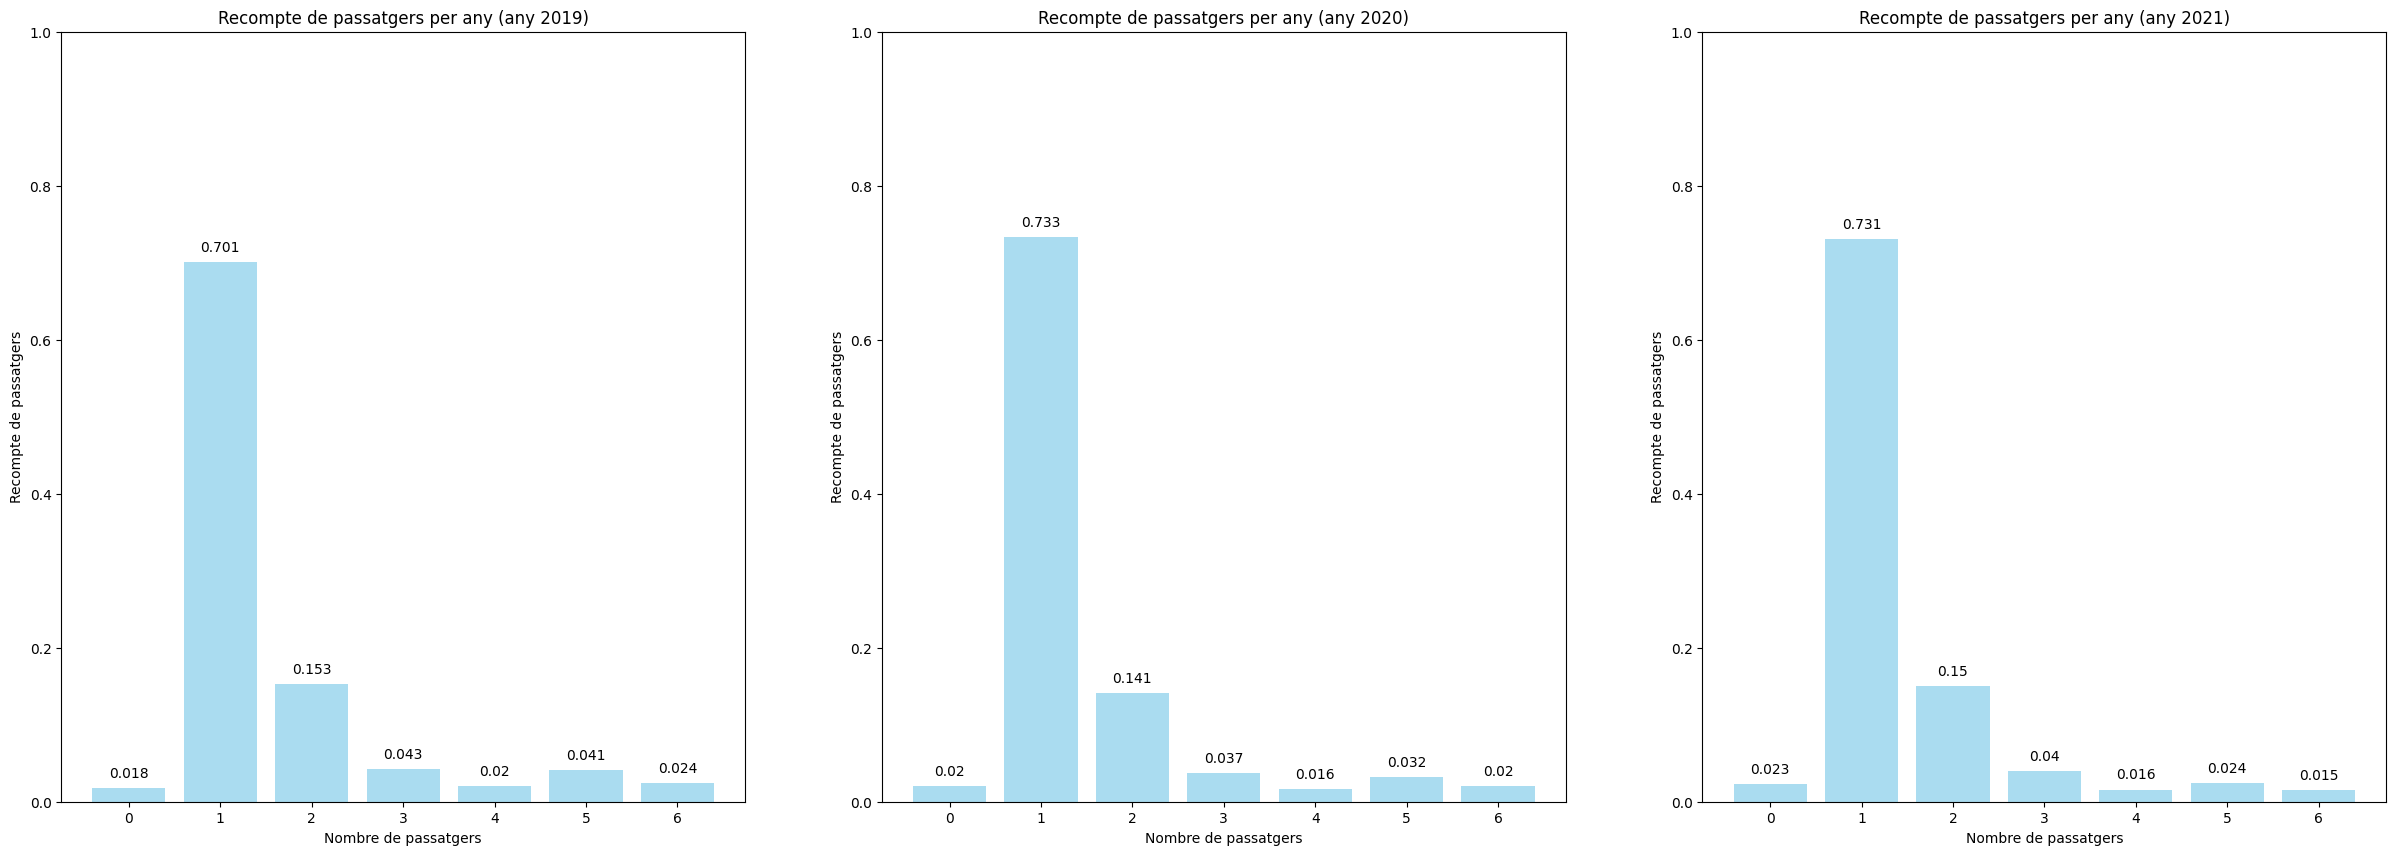

In [ ]:
passengers_taxi_year(df,
                     (0, 1),
                     'Nombre de passatgers',
                     'Recompte de passatgers',
                     'Recompte de passatgers per any',
                     True)

* Resposta
    * Ara que normalitzem les dades podem tenir una visió global de la porció que implica cada part. Com ja hem dit abans, el viatges d'una persona són sempre els més populars i es dona un fet molt curiòs: els anys 2020 i 2021 tenen més percentatge de viatges d'una persona que els del 2019. El motiu és clar però contraintuitiu. Això és perque els dos darrers anys no s'han fet molts viatges multipersonals i per tant, els viatges unipersonals tenen més protagonisme. Un altre cop, això és causat per les mesures santiaries.

    * Obsrevem però, que encara que es dona aquest fet, la repartició dels viatges es bastant constant al llarg dels anys. El viatge més popular és d'una persona i el menys comú és el de 4.

+ Com descriurieu de forma **qualitativa** l'efecte de la covid sobre els taxis en base a l'anàlisi fet fins ara?
+ Podeu calcular de forma **quantitativa** la magnitud dels canvis que heu detectat? Escriviu una funció que calculi una sèrie d'indicadors quantitatius (per exemple, quin canvi percentual hi ha en el nombre de viatges d'una sola persona, la mitja de passatgers per viatge, etc.).

In [ ]:
def column_descriptors(df, column, stat):
  """
  Funció que visualitza dades estadístiques de cada any segons el mes

  Parameters:
  - df (DataFrame): El DataFrame amb el que treballem.
  - colum (str): Columna que volem estudiar.
  - stat (str): Dada estadística que volem visualitzar.
  """

  fig, axes = plt.subplots(3, 1, figsize=(15, 10))
  fig.suptitle(column, fontsize=16)
  axes = axes.ravel()

  for i, year in enumerate(YEARS):

    yearly_data = df[df['year'] == year]

    if column not in yearly_data.columns:
      raise KeyError("This DataFrame does not contain such column")

    # Utilitzem group by per agrupar les dades pel mes
    monthly_data = yearly_data.groupby('month')[column]
    indicators = monthly_data.describe()

    if stat not in indicators.keys():
      raise KeyError("Invalid key")

    indicator = indicators[stat]

    # Dibuixem els gràfics
    bars = axes[i].bar(indicator.index, indicator.values, color='skyblue', alpha=0.7)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_title(f'{stat} ({year})')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(f'{stat}')

    # Afegim el valor adalt de la barra
    for bar in bars:
      yval = bar.get_height()
      axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), ha='center', va='bottom')

  plt.tight_layout()
  plt.show()

In [1]:
# Cridem les funcions per obtenir les dades i graficar-les
column_descriptors(df,
                   'passenger_count',
                   'mean')

NameError: name 'column_descriptors' is not defined

* Resposta:
    * Tornem a vuere una distribució molt semblant a les que hem comentat anteriorment. Entre el març i l'abril del 2020 es dona una disminució dels viatges molt acusada a causa de la pandèmia. Pel que fa a la mitjana de passatgers, tot i que ho comentarem una mica més a baix, els viatges unipersonals baixen en menor grau, suposem que per evitar contagis amb altres passatgers.

In [ ]:
def passenger_number_evolution(df, column, ylim, xlabel, ylabel, title, norm = False):
    """
    Evolució d'algunes dades estadístiques

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - column (str): Columna que volem estudiar.
    - ylim (range): Límit que tindran els nostres valors.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    - title (str): Títol de la taula.
    - norm (boolean): Indicador sobre si hem de normalitzar o no les dades.
    """

    plt.figure(figsize=(14, 6))

    # Definir una llista per emmagatzemar les variacions percentuals
    first_year_data = None

    for i, year in enumerate(YEARS):
        # Filtrem el DataFrame per un any en particular
        yearly_trips = df[df['year'] == year]

        if column not in yearly_trips.columns:
          raise KeyError("This DataFrame does not contain such column")

        evolution = yearly_trips[column].value_counts(normalize=norm).sort_index()

        if first_year_data is None:
            # Per al primer any, establir la variació a 0
            percentage_change = evolution * 0
            # Actualitzar les dades de l'any anterior per a la propera iteració
            first_year_data = evolution

        else:
            # Calcular la variació percentual respecte a l'any anterior
            percentage_change = ((evolution - first_year_data) / first_year_data)

            # Mostrem la informació
            bars = plt.bar(percentage_change.index + 0.3*(i-1), percentage_change.values, label=f'{year}', width=0.3, alpha=0.7)
            plt.xticks(evolution.index)

            # Afegim el valor adalt de la barra
            for bar in bars:
                yval = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), ha='center', va='bottom')

    plt.axhline(0, color='black', linewidth=0.7, linestyle='-')
    plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(ylim)
    plt.show()

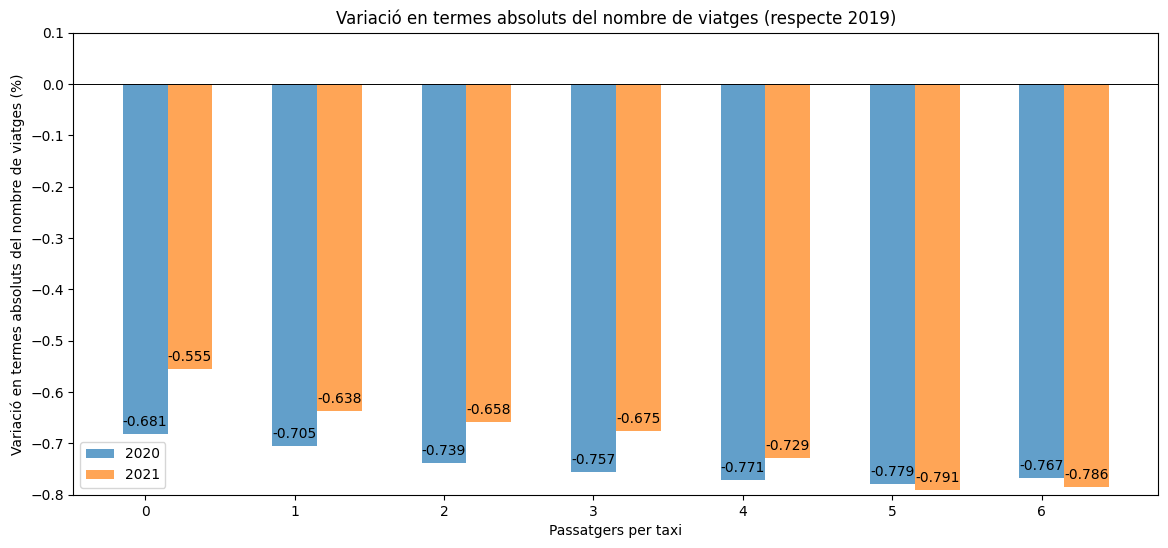

In [ ]:
passenger_number_evolution(df,
                           'passenger_count',
                            (-0.8, 0.1),
                           'Passatgers per taxi',
                           'Variació en termes absoluts del nombre de viatges (%)',
                           'Variació en termes absoluts del nombre de viatges (respecte 2019)')

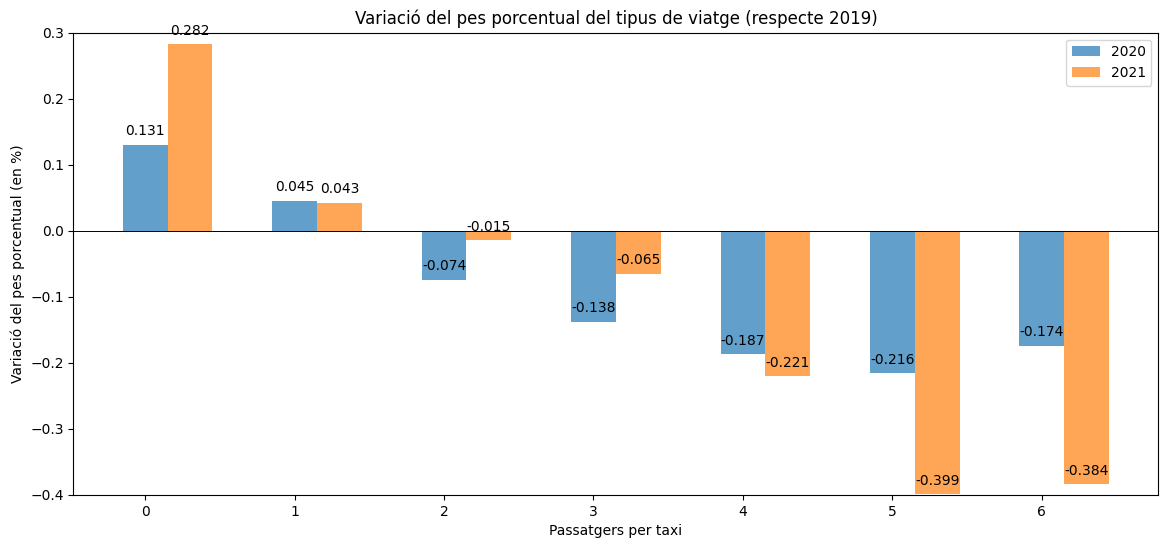

In [ ]:
passenger_number_evolution(df,
                           'passenger_count',
                            (-0.4, 0.3),
                           'Passatgers per taxi',
                           'Variació del pes porcentual (en %)',
                           'Variació del pes porcentual del tipus de viatge (respecte 2019)',
                           True)

Si ens fixem en el cas `passenger_count = 1`, el nombre de passatgers
decreix sensiblement menys que aquells viatges que portaven més passatgers. Dit d'una altra manera, els viatges amb 4 o més persones són els que s'han vist més afectats. També veiem que cau més els viatges de 5 o 6 persones al 2021 que al 2020.

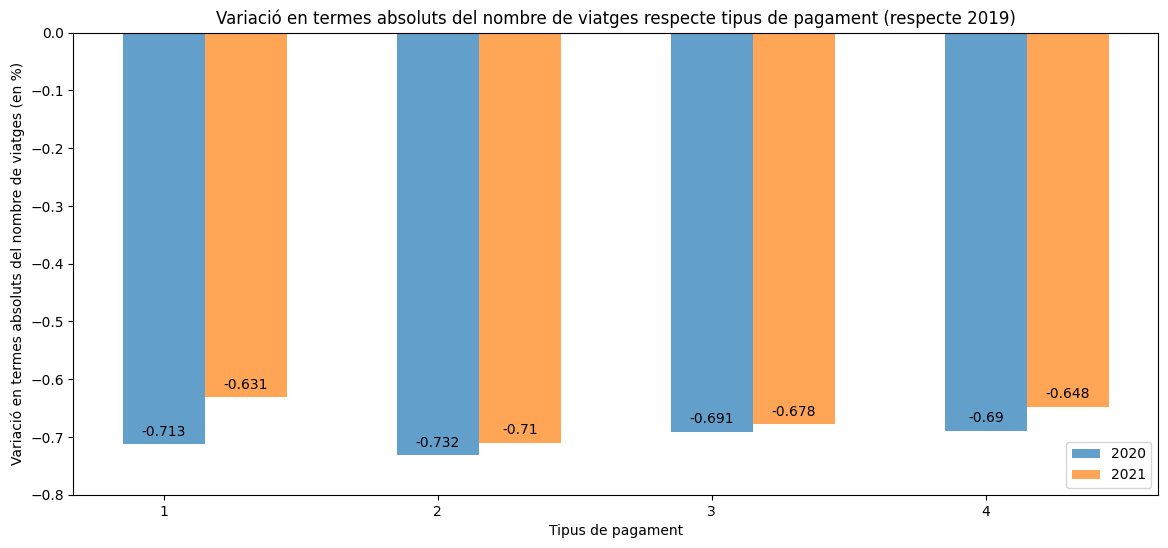

In [ ]:
passenger_number_evolution(df,
                           'payment_type',
                           (-0.8, 0),
                           'Tipus de pagament',
                           'Variació en termes absoluts del nombre de viatges (en %)',
                           'Variació en termes absoluts del nombre de viatges respecte tipus de pagament (respecte 2019)',
                           False)

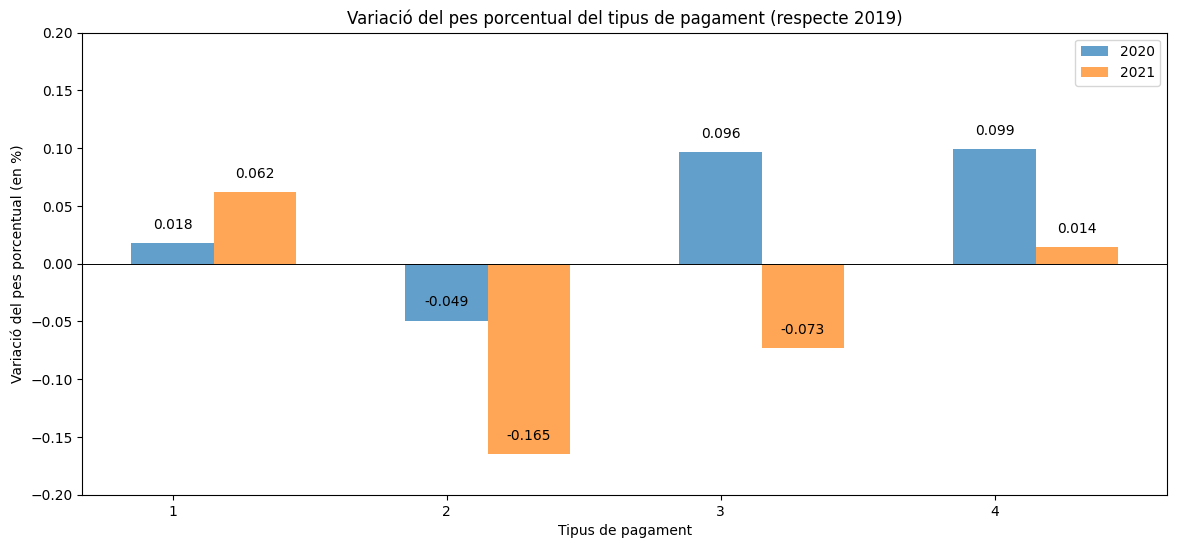

In [ ]:
passenger_number_evolution(df,
                           'payment_type',
                            (-0.2, 0.2),
                           'Tipus de pagament',
                           'Variació del pes porcentual (en %)',
                           'Variació del pes porcentual del tipus de pagament (respecte 2019)',
                           True)

Observem la tendència mundial després de la covid de començar a pagar amb targeta. Sobre tot al 2021, hi ha una disminució d'un 16,5% del pes porcentual del nombre de viatges que van ser pagats en efectiu. És a dir, un 16,5% dels viatges va ser pagat per altres mitjans.

## 4. Quantitat de viatges

Fins ara hem vist la quantitat de viatges que hi ha hagut a nivell de mesos i anys.

Ara podem estudiar l'efecte de la covid en el nombre de trajectes si **agreguem** les dades per hores, dies de la setmana, setmanes de l'any, etc.

### Exercici D

+ Escriu una única funció genèrica que visualitzi el nombre de trajectes per les agregacions de dades comentades i per cada any. Fes servir gràfics de línies discontínues (una línia per cada any) per veure'n l'evolució i marca amb una rodona o creu allà on està el valor.

In [ ]:
def visualize_trips(df, columns, title, xlabel, ylabel):
    """
    Funció que visualitza els viatges per diferents agregacions de dades

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - columns (list): Columnes que comparem.
    - title (str): Títol de la taula.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    """

    if not isinstance(columns, list):
        print("Ens estàs passant unes columnes en format invàlid")
        return

    fig, axes = plt.subplots(len(columns), 1, figsize=(15, 10))

    # En cas de tenir una llista, iterem pels seus valors
    for i, column in enumerate(columns):
        for year in YEARS:
            # Creem les gràfiques
            trips = df.loc[df['year'] == year]
            trips = trips[column].value_counts().sort_index()
            axes[i].plot(trips.index, trips.values, linestyle='--', marker='o', label=f'{year}')
        axes[i].legend()
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)
        axes[i].set_title(f"{title} ({column})")

    plt.tight_layout()
    plt.show()

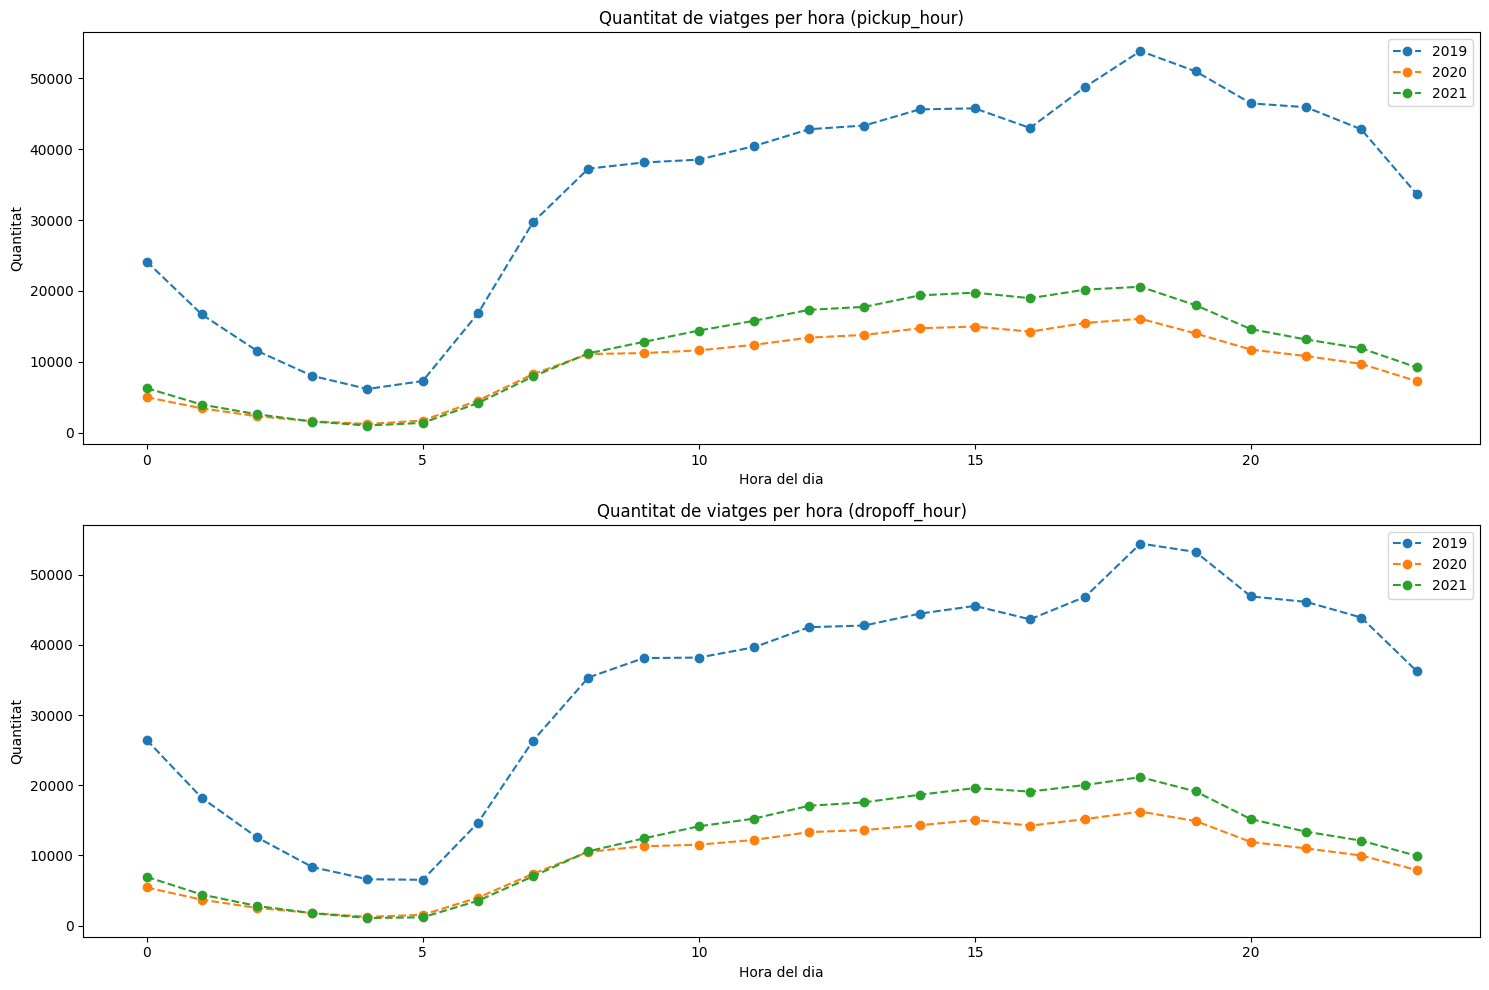

In [ ]:
visualize_trips(df,
                ['pickup_hour', 'dropoff_hour'],
                'Quantitat de viatges per hora',
                'Hora del dia',
                'Quantitat')

* Resposta
    * Basat en l'anàlisi de les gràfiques proporcionades, es pot observar que, tot i que la forma de la distribució horària dels viatges es manté constant durant els tres anys (2019, 2020, i 2021), el que canvia significativament és la magnitud de viatges per hora. Els patrons segueixen la mateixa tendència: a la matinada, la quantitat de viatges és baixa, i al voltant de les 5h del matí comença un creixement considerable a mesura que les persones inicien la seva jornada laboral. Aquest augment es manté fins a les 9h, moment en què el nombre de viatges es manté estable fins a les 16-18h, on es veu un altre pic significatiu, coincidint amb la sortida de la feina de moltes persones. Després de les 19h, el nombre de viatges decau considerablement.

    * El 2020 mostra una caiguda dràstica en el nombre total de viatges a causa de les restriccions provocades per la COVID-19, i tot i que el 2021 hi ha una lleugera recuperació, encara està lluny dels nivells prepandèmics del 2019. Aquest patró indica que, tot i els canvis en la mobilitat general, la distribució horària de la demanda de taxis ha estat bastant estable, reflectint hàbits diaris que no han variat malgrat la pandèmia.

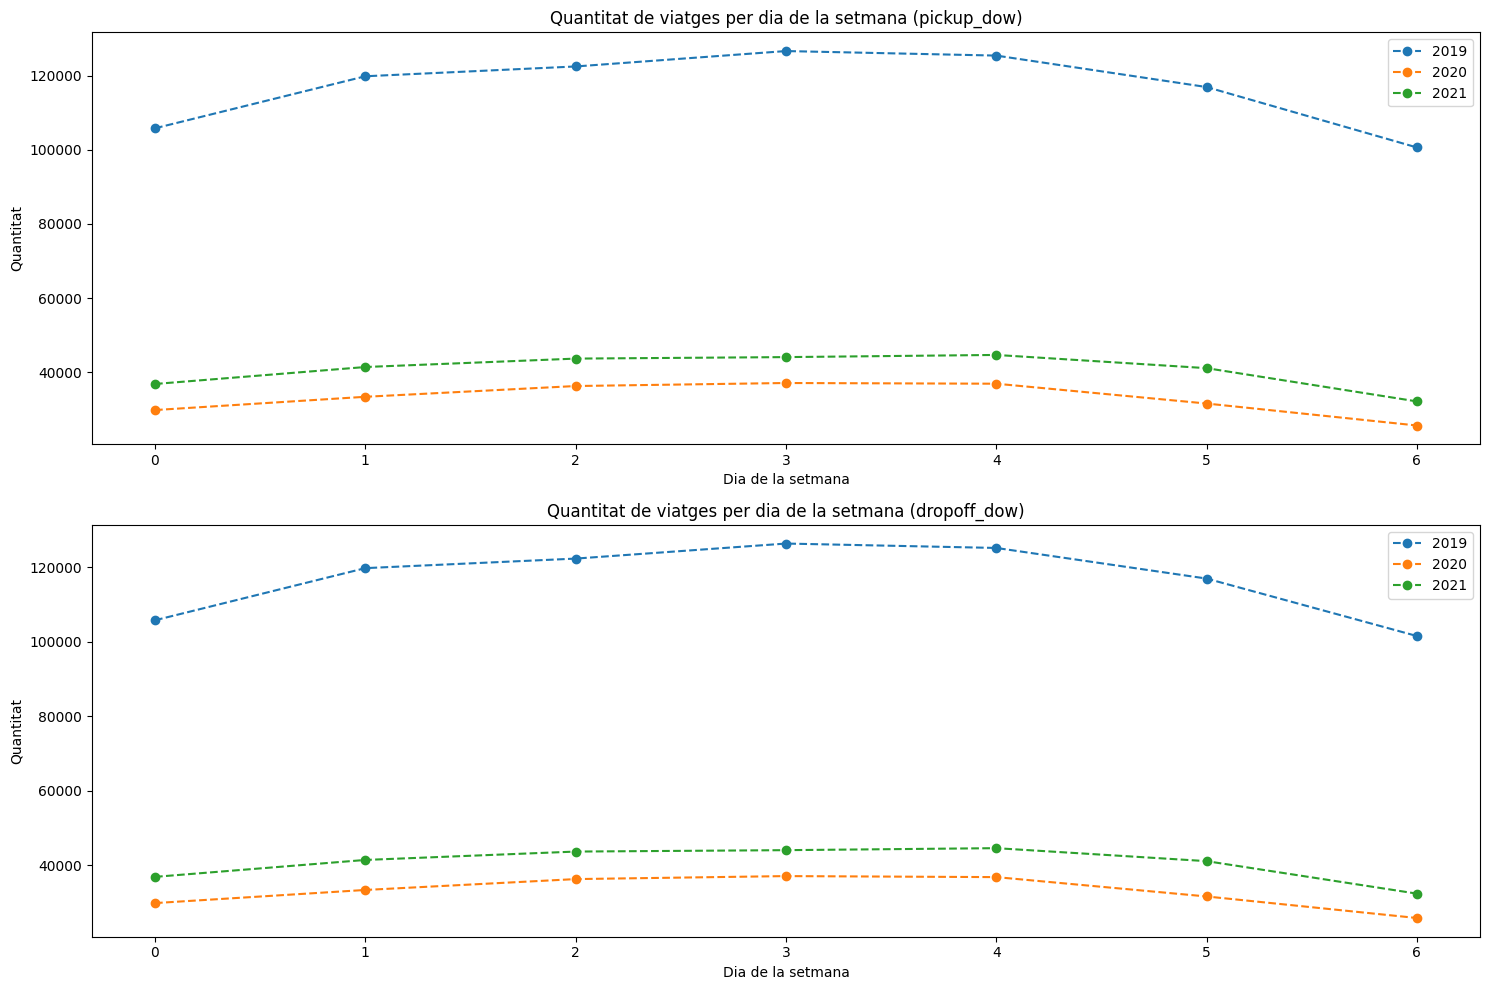

In [ ]:
visualize_trips(df,
                ['pickup_dow', 'dropoff_dow'],
                'Quantitat de viatges per dia de la setmana',
                'Dia de la setmana',
                'Quantitat')

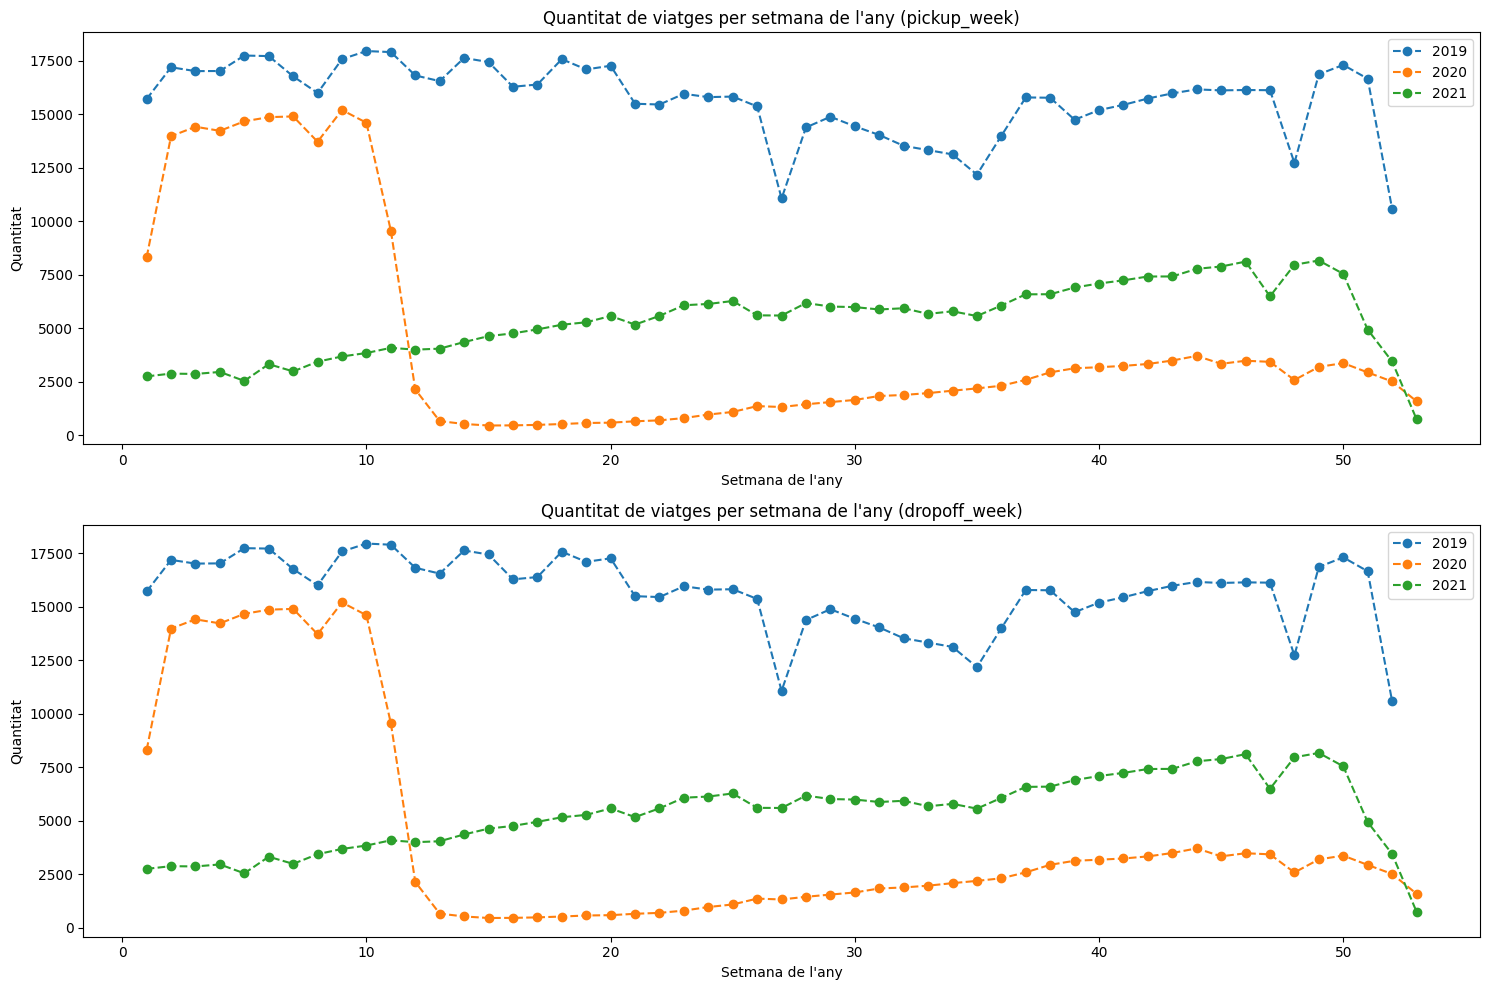

In [ ]:
visualize_trips(df,
                ['pickup_week', 'dropoff_week'],
                'Quantitat de viatges per setmana de l\'any',
                'Setmana de l\'any',
                'Quantitat')

+ Com descriurieu l'efecte de la covid en cada cas (si és que en té)? Quin creieu que és el motiu?

> Resposta:

  * Les gràfiques de la quantitat de viatges per setmana de l'any mostren variacions significatives en determinats períodes, especialment en setmanes relacionades amb festes nacionals i les onades de COVID-19. Aquestes variacions es poden correlacionar amb esdeveniments i circumstàncies especials com el Dia de la Independència, Thanksgiving i Nadal, així com les diverses onades de la pandèmia que van afectar Nova York.

    1. Les dates festives que més influeix a la disminució de la quantitat de viatges en taxi son el Dia de la Independència (setmana 27), Thanksgiving (setmana 47) i Nadal (setmanes 51-52). Observem que aquest comportament es repeteix els tres anys però el 2019 és on més canvi va haver-hi. A causa de la pandèmia aquesta tendència es va suavitzar un pel.

    2. L'impacte de les onades de COVID-19 es reflecteix clarament en les gràfiques. La primera onada (març-juny 2020) va causar una caiguda dràstica en els viatges a causa dels confinaments, això es pot veure reflectit en la gràfica taronja. La segona onada (tardor 2020-hivern 2021) va interrompre la recuperació, especialment durant el període nadalenc, ho podem veure a la linea taronja. La tercera onada (primavera-estiu 2021) va veure una recuperació progressiva gràcies a la vacunació, mentre que la quarta onada (hivern 2021) va causar una nova caiguda. Les conseqüencies d'aquestes dues onades es veuen a la linea verda.

## 5. Relació distancia, temps i velocitat

A les dades tenim la **distància** que ha recorregut el taxi en cada viatge i de la informació temporal podem extreure també la **durada** d'aquest.

Ara explorarem com la covid va afectar les distàncies i les durades dels viatges, i també la velocitat dels taxis. També ens preguntarem si la densitat de trànsit va variar.

### Exercici E

+ Per començar, escriu una funció que visualitzi els **histogrames** de distància i durada per any.

In [ ]:
def visualize_histograms(df, column, title, xlabel, ylabel, xlim):
    """
    Funció que crea un histograma a partir de la informació que conté la columna del dataframe

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - column (str): Columna que volem estudiar.
    - title (str): Títol de la taula.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    - xlim (range): Límit que tindran els nostres valors.
    """

    # Creem el gràfic
    plt.figure(figsize=(15,6))

    # Comptem els viatges per cada any
    for year in YEARS:

        data = df[df['year'] == year]
        kwargs = dict(histtype='bar', alpha=0.5, bins=50, label=f'{year}')

        plt.hist(data[column], **kwargs)

    # Configurem el plt
    plt.legend(title="Year")
    plt.xlim(xlim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

* Com creieu que la covid va afectar les distàncies i durades dels viatges?

* I a la velocitat dels taxis?

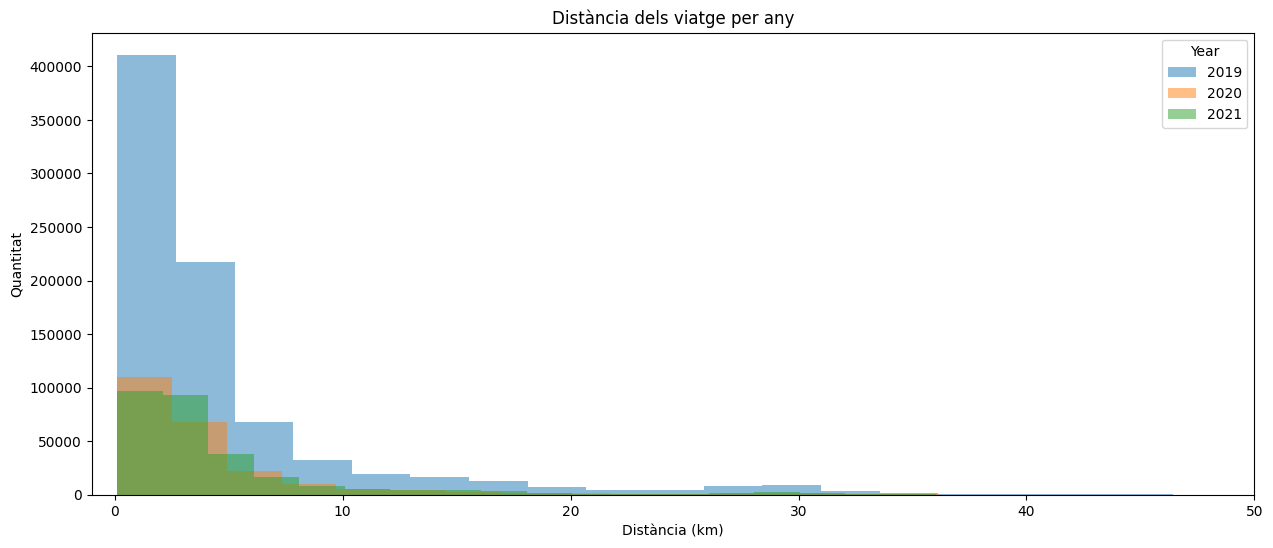

In [ ]:
visualize_histograms(df,
                     'trip_distance',
                     'Distància dels viatge per any',
                     'Distància (km)',
                     'Quantitat',
                      (-1, 50))

* Resposta:
    * La disminució de la quantitat de viatges és generalitzada, però la distribució és semblant tots els anys i veiem que la moda està entre els 0 i els 5km de distància per viatge. Això és perquè la majoria de viatges són urbans i, per tant, bastant curts.
    * La disminució en el nombre de viatges és especialment acusada en els viatges "llargs".

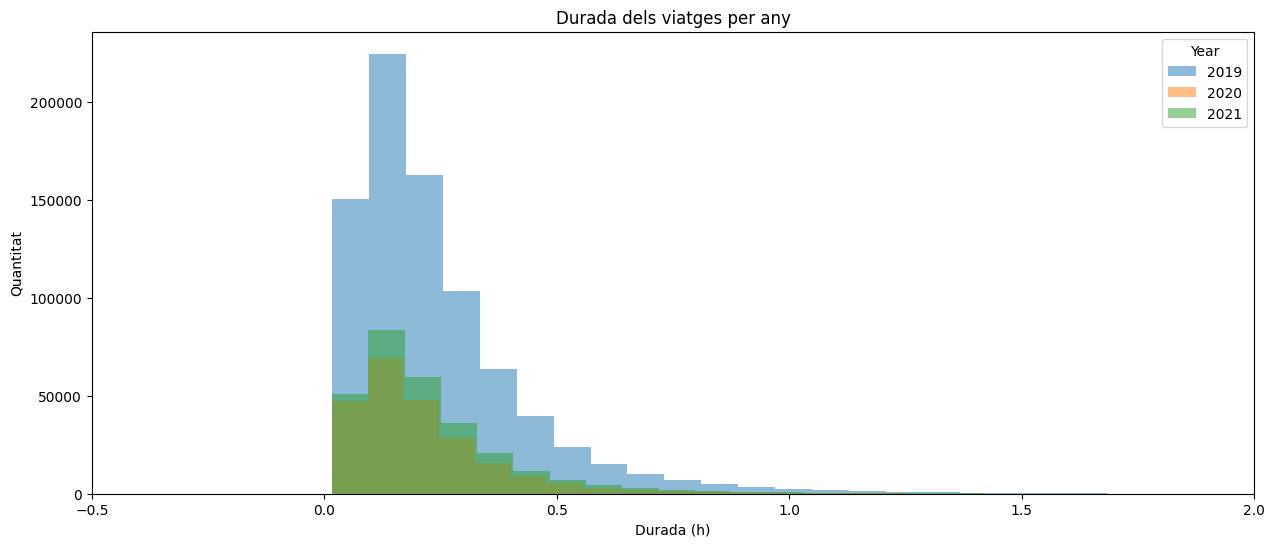

In [ ]:
visualize_histograms(df,
                     'travel_time',
                     'Durada dels viatges per any',
                     'Durada (h)',
                     'Quantitat',
                      (-0.5, 2))

* Resposta:
    * La distribució és pràcticament igual a tots els anys i veiem que la moda està en menys de 20 minuts de viatge. Això és, un altre cop, perquè les distàncies a NY són curtes i, per tant, el temps del viatge també tendirà a ser-ho.

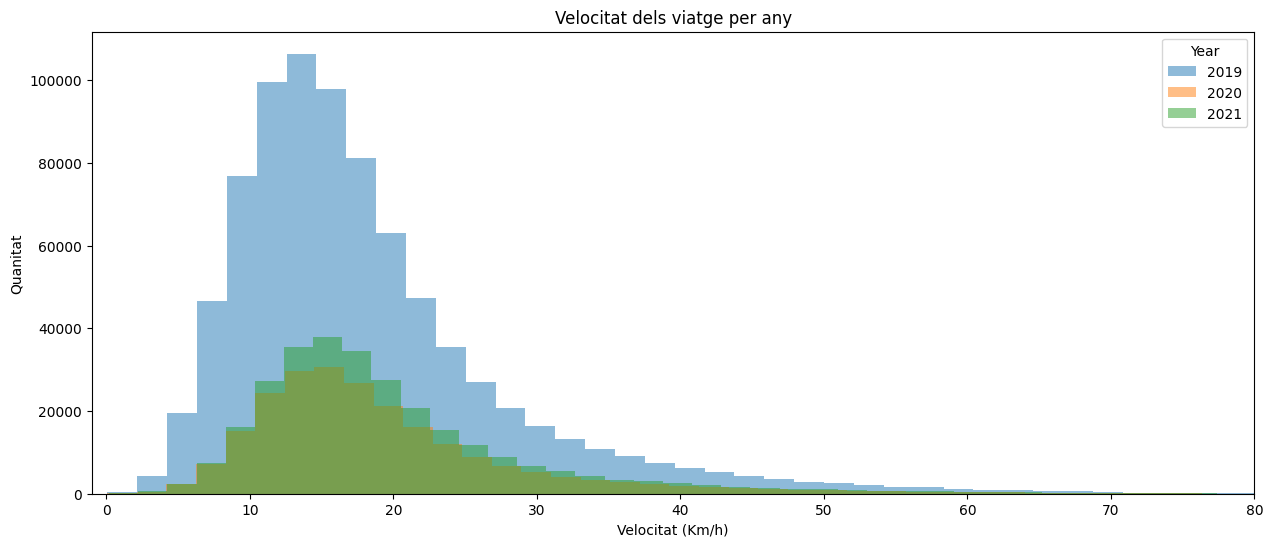

In [ ]:
visualize_histograms(df,
                     'avg_speed',
                     'Velocitat dels viatge per any',
                     'Velocitat (Km/h)',
                     'Quanitat',
                     (-1, 80))

* Resposta:
    * La distribució és semblant tots els anys. La majoria de viatges son de 15km/h. Això sembla un valor molt petit però s'ha de tenir en compte que el càlcul s'ha fet agafant la distància total del viatge entre el temps transcorregut, sense tenir en compte el tràfic, els semàfors, etc. Per tant aquest valor pot estar esbiaixat. Val a dir que el pic de viatges al 2019 està més a l'esquerra que al 2020 i 2021, el que porta a pensar que la disminució de tràfic a causa de la pandèmia podria haver permès augmentar lleugerament la velocitat mitjana dels viatges.

https://data.cityofnewyork.us/Transportation/NYC-Taxi-Zones/d3c5-ddgc

+ Utilitzant el DataFrame, escriu una funció que identifiqui les cinc ubicacions de recollida (PULocationID) més freqüents.
+ Per a aquestes cinc ubicacions de recollida, calcula el nombre mitjà de passatgers (passenger_count) per trajecte.
+ Filtra els trajectes on la ubicació de recollida i de deixada són la mateixa (PULocationID == DOLocationID). Calcula el percentatge d'aquests trajectes respecte al total de trajectes.

In [ ]:
def analyze_pickup_dropoff_locations(data):
    """
    Funció que analitza dades estadístiques quan PULocationID == DOLocationID

    Parameters:
    - data (DataFrame): El DataFrame amb el que treballem.
    """

    fig, axes = plt.subplots(2, figsize=(15, 10))

    # 1. Obtenim les 5 ubicacions de recollida més freqüents
    # Com que sort_values ordena en ordre ascendent hem d'agafar tail
    trips = data['PULocationID'].value_counts().sort_values().tail(5)

    # Mostrem els viatges on la location ID sigui una de les que hem trobat abans
    pickup_locations = data[data['PULocationID'].isin(trips.keys())]

    # Fem reset del índex per tenir-ho actualitzat
    pickup_locations.reset_index(drop=True, inplace=True)

    print('La taula amb les 5 ubicacions de recollida més freqüents són:')
    display(pickup_locations)

    # 2. Calculem el nombre mitjà de passatgers per trajecte
    pu_plot = pickup_locations.groupby('PULocationID')['passenger_count'].mean()

    # Dibuixem i afegim els valors a sobre de cada barra
    bars = axes[0].bar(pu_plot.index.astype(str), pu_plot.values, color='skyblue', alpha=0.7)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}',
                     ha='center', va='bottom', fontsize=10)

    axes[0].set_ylim((0, 1.6))
    axes[0].set_xlabel("Ubicacions més freqüents")
    axes[0].set_ylabel("Mitjana de passatgers")
    axes[0].set_title("Mean passenger_count per ubicació més freqüent")


    # 3. Busquem els trajectes tals que PU == DO
    equal_pudo_table = data[data['PULocationID'] == data['DOLocationID']].reset_index(drop=True)
    pudo_plot = equal_pudo_table['PULocationID'].value_counts().sort_index()

    # Dibuixem i afegim els valors a sobre de cada barra
    pudo_bars = axes[1].bar(pudo_plot.index.astype(str), pudo_plot.values, color='skyblue', alpha=0.7)
    # Mostrem només els xticks per les ubicacions amb valors per sobre del llindar
    visible_ticks = [str(tick) if pudo_plot[tick] > 2000 else '' for tick in pudo_plot.index]
    axes[1].set_xticks(range(len(pudo_plot)))  # Assegurem que els ticks es configuren correctament
    axes[1].set_xticklabels(visible_ticks, rotation=90, ha='center', fontsize=5)

    axes[1].set_ylim((0, 3000))
    axes[1].set_xlabel("Ubicacions totals")
    axes[1].set_ylabel("Quantitat de viatges PU==DO")
    axes[1].set_title("Quantitat de viatges PU==DO per ubicació")

    print('\nLa taula tal que PU==DO és:')
    display(equal_pudo_table)

    equal_pudo_table_rows, equal_pudo_table_columns = equal_pudo_table.shape
    data_rows, data_columns = data.shape

    # Calculem el quocient demanat
    percentatge_de_trajectes = (equal_pudo_table_rows / data_rows) * 100
    print(f'La relació entre els viatges amb PU=DO és: {percentatge_de_trajectes}%')

    # Configurem el fig
    fig.tight_layout()
    fig.show()

La taula amb les 5 ubicacions de recollida més freqüents són:


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,total_amount,travel_time,...,dropoff_hour,pickup_day,dropoff_day,pickup_dow,dropoff_dow,pickup_week,dropoff_week,month,year,quarter
0,2019-01-01 00:34:48,2019-01-01 00:46:16,2.0,3.234773,236,74,1,10.0,12.88,0.191111,...,0,1,1,1,1,1,1,1,2019,1
1,2019-01-01 00:47:19,2019-01-01 01:03:21,1.0,3.057746,161,137,2,11.5,12.80,0.267222,...,1,1,1,1,1,1,1,1,2019,1
2,2019-01-01 00:35:45,2019-01-01 00:39:38,2.0,1.190912,237,162,2,5.0,6.30,0.064722,...,0,1,1,1,1,1,1,1,2019,1
3,2019-01-01 00:44:45,2019-01-01 00:55:19,6.0,2.848532,161,143,1,9.0,12.36,0.176111,...,0,1,1,1,1,1,1,1,2019,1
4,2019-01-01 00:05:54,2019-01-01 00:25:09,1.0,6.485640,161,41,1,15.0,19.56,0.320833,...,0,1,1,1,1,1,1,1,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268154,2021-12-31 22:39:22,2021-12-31 22:55:45,1.0,4.956767,161,68,1,13.5,20.76,0.273056,...,22,31,31,4,4,52,52,12,2021,4
268155,2021-12-31 23:45:59,2021-12-31 23:47:17,1.0,0.820763,236,236,1,3.5,8.76,0.021667,...,23,31,31,4,4,52,52,12,2021,4
268156,2021-12-31 23:44:43,2021-12-31 23:57:48,2.0,0.869044,161,164,2,9.0,12.80,0.218056,...,23,31,31,4,4,52,52,12,2021,4
268157,2021-12-31 23:24:02,2021-12-31 23:35:34,2.0,1.609340,161,237,1,8.5,17.30,0.192222,...,23,31,31,4,4,52,52,12,2021,4



La taula tal que PU==DO és:


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,total_amount,travel_time,...,dropoff_hour,pickup_day,dropoff_day,pickup_dow,dropoff_dow,pickup_week,dropoff_week,month,year,quarter
0,2019-01-01 00:58:15,2019-01-01 01:04:23,4.0,2.253076,112,112,1,6.5,10.92,0.102222,...,1,1,1,1,1,1,1,1,2019,1
1,2019-01-01 00:49:22,2019-01-01 00:52:38,1.0,0.981697,145,145,2,4.5,5.80,0.054444,...,0,1,1,1,1,1,1,1,2019,1
2,2019-01-01 00:08:18,2019-01-01 00:26:41,1.0,1.834648,161,161,2,11.5,12.80,0.306389,...,0,1,1,1,1,1,1,1,2019,1
3,2019-01-01 00:11:35,2019-01-01 00:15:55,1.0,0.611549,234,234,2,4.5,5.80,0.072222,...,0,1,1,1,1,1,1,1,2019,1
4,2019-01-01 00:56:32,2019-01-01 00:59:25,2.0,0.756390,237,237,2,4.0,5.30,0.048056,...,0,1,1,1,1,1,1,1,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64126,2021-12-31 21:16:51,2021-12-31 21:20:11,3.0,0.997791,48,48,1,4.5,10.79,0.055556,...,21,31,31,4,4,52,52,12,2021,4
64127,2021-12-31 21:03:49,2021-12-31 21:09:50,1.0,0.997791,161,161,2,4.5,8.30,0.100278,...,21,31,31,4,4,52,52,12,2021,4
64128,2021-12-31 22:21:20,2021-12-31 22:26:37,1.0,1.013884,237,237,2,5.5,9.30,0.088056,...,22,31,31,4,4,52,52,12,2021,4
64129,2021-12-31 23:45:59,2021-12-31 23:47:17,1.0,0.820763,236,236,1,3.5,8.76,0.021667,...,23,31,31,4,4,52,52,12,2021,4


La relació entre els viatges amb PU=DO és: 4.812656044918423%


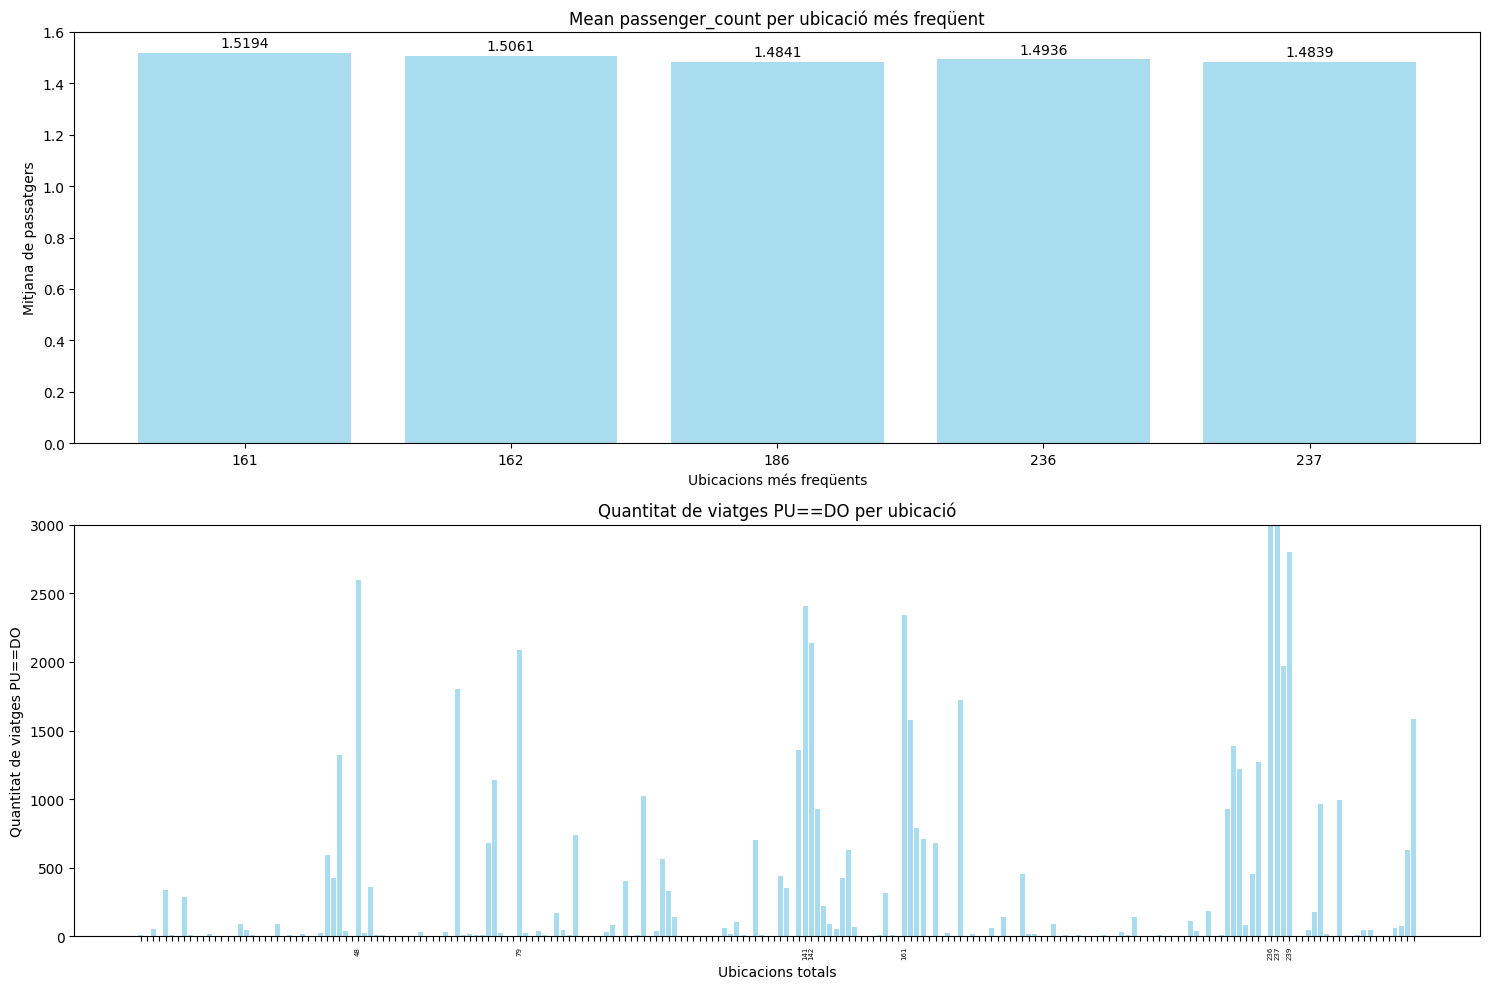

In [ ]:
analyze_pickup_dropoff_locations(df)

* Resposta
  * La primera gràfica ens mostra que les ubicacions més freqüents són les
    1. Zona 161: Prospect-Lefferts Gardens (Brooklyn). Hi ha un dels parcs més grans de New York.
    2. Zona 162: Prospect Heights (Brooklyn). Aquí es troba el Barklays Center. Entre d'altres, és el pavelló dels Brooklyn Nets, l'equip de bàsquet de Brooklyn.
    3. Zona 186: South Ozone Park (Queens). És una zona que està molt propera a l'aeroport JFK, un dels més grans del món.
    4. Zona 236: West Village (Manhattan). És una zona turística i residencial molt gran.
    5. Zona 237: World Trade Center (Manhattan). És un destí comercial i turístic molt important per la ciutat. Hi ha empreses, oficines i el 9/11 Memorial.

  * La segona gràfica mostra la quantitat de viatges que comencen i acaben en la mateixa ubicació. Destaquen:
    1. Zona 48: Central Park South (Manhattan). És la zona del famos parc de New York, molta gent el visita.
    2. Zona 79: East Harlem North (Manhattan). Zona residencial amb molta població.
    3. Zona 141: Morningside Heights (Manhattan). És la zona on està la Universitat de Columbia. Utilitzen aquest servei molts estudiants, professors i treballadors.
    4. Zona 142: Morrisania/Melrose (Bronx). Area residencial del Bronx.
    5. Zona 161: Prospect-Lefferts Gardens (Brooklyn). Ja ho hem vist abans.
    6. Zona 236: West Village (Manhattan). Ja ho hem vist abans.
    7. Zona 237: World Trade Center (Manhattan). Ja ho hem vist abans.
    8. Zona 239: Yorkville West (Manhattan). És una zona residencial en el Upper East Side de Manhattan. Està a prop de Central Park i del districte hospitalari.